# Comparison of Neural Decoding Methods: From Single Neurons to Population Coding

In this project, we explore how the brain encodes information about external stimuli in neural activity and more importantly, how we can "read out" this information using different decoding strategies.

The main idea is simple: neurons respond to stimuli by firing spikes, and the pattern of this activity contains information about what the stimulus was. But how do we extract this information? And which decoding method works best under different conditions?

We start with the classical Bayesian approach, then implement several alternative decoders (Maximum Likelihood, Linear Classifier), and systematically compare their performance. Along the way, we investigate how factors like the number of neurons, noise correlations, and stimulus discriminability affect decoding accuracy.

**Key questions we address:**
- How does decoding accuracy scale with population size?
- Do noise correlations between neurons help or hurt decoding?
- Which decoder performs best when the signal is weak?

This project builds upon the Bayesian decoding framework introduced in the course and extends it to a more realistic population coding scenario.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm
from scipy.special import softmax
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Simulating Neural Population Responses

Before we can decode anything, we need to simulate realistic neural data. Here we create a population of neurons that respond to different stimuli with different firing rates.

The basic model: each neuron fires according to a Poisson process, where the firing rate depends on which stimulus is presented. Different neurons have different "preferences": some respond more strongly to stimulus A, others to stimulus B, and so on.

We also add the option to introduce noise correlations between neurons, which is important for understanding real neural populations.

In [ ]:
def simulate_population_response(firing_rates, n_trials, time_window=0.1, correlation=0.0):
    n_stimuli, n_neurons = firing_rates.shape
    expected_counts = firing_rates * time_window
    spike_counts = np.zeros((n_stimuli, n_trials, n_neurons))

    for s in range(n_stimuli):
        if correlation == 0:
            # Independent Poisson neurons
            for n in range(n_neurons):
                spike_counts[s, :, n] = np.random.poisson(expected_counts[s, n], n_trials)
        else:
            # Correlated neurons using a common noise source
            for t in range(n_trials):
                common_noise = np.random.randn()
                for n in range(n_neurons):
                    # Mix of private and shared noise
                    private_noise = np.random.randn()
                    combined_noise = correlation * common_noise + np.sqrt(1 - correlation**2) * private_noise
                    # Modulate rate by noise, then sample Poisson
                    modulated_rate = expected_counts[s, n] * np.exp(0.5 * combined_noise)
                    spike_counts[s, t, n] = np.random.poisson(max(0, modulated_rate))

    return spike_counts

Now let's define our experimental setup. We'll use 4 different stimuli and a population of 10 neurons. Each neuron has a "preferred" stimulus that makes it fire more strongly.

In [ ]:
# Experimental parameters
n_stimuli = 4
n_neurons = 10
n_trials = 200  # trials per stimulus
time_window = 0.1  # 100 ms observation window

# Create firing rates: each neuron has a preferred stimulus. Base rate is low, preferred stimulus gives high rate
base_rate = 10
preferred_rate = 25

# Also add some variability: not all neurons are equally selective
preferred_stimulus = np.array([i % n_stimuli for i in range(n_neurons)])

# Build firing rate matrix with some heterogeneity
firing_rates = np.ones((n_stimuli, n_neurons)) * base_rate

for n in range(n_neurons):
    # Add some randomness to preferred rates (not all neurons equally good)
    neuron_selectivity = preferred_rate + np.random.uniform(-5, 5)
    firing_rates[preferred_stimulus[n], n] = neuron_selectivity

print("Firing rate matrix (stimuli x neurons):")
print(np.round(firing_rates, 1))
print(f"\nRate difference: {preferred_rate} vs {base_rate} Hz (ratio: {preferred_rate/base_rate:.1f}x)")

Firing rate matrix (stimuli x neurons):
[[23.7 10.  10.  10.  21.6 10.  10.  10.  26.  10. ]
 [10.  29.5 10.  10.  10.  21.6 10.  10.  10.  27.1]
 [10.  10.  27.3 10.  10.  10.  20.6 10.  10.  10. ]
 [10.  10.  10.  26.  10.  10.  10.  28.7 10.  10. ]]

Rate difference: 25 vs 10 Hz (ratio: 2.5x)


Let's visualize the firing rate matrix to make sure our setup makes sense. Each row is a stimulus, each column is a neuron. You can see the "diagonal" pattern, neurons respond strongly to their preferred stimulus.

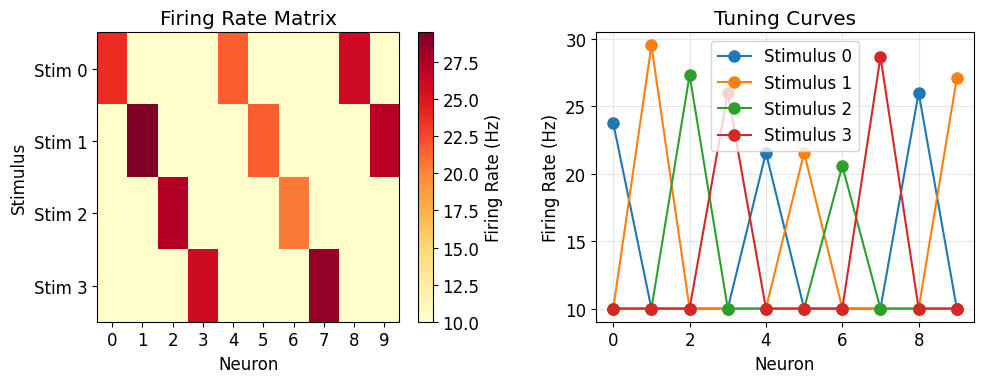

In [ ]:
# Visualize the firing rate matrix
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(firing_rates, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Firing Rate (Hz)')
plt.xlabel('Neuron')
plt.ylabel('Stimulus')
plt.title('Firing Rate Matrix')
plt.xticks(range(n_neurons))
plt.yticks(range(n_stimuli), [f'Stim {i}' for i in range(n_stimuli)])

plt.subplot(1, 2, 2)
for s in range(n_stimuli):
    plt.plot(firing_rates[s, :], 'o-', label=f'Stimulus {s}', markersize=8)
plt.xlabel('Neuron')
plt.ylabel('Firing Rate (Hz)')
plt.title('Tuning Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now we generate the actual spike count data. We run many trials for each stimulus. This gives us the "training" data that our decoders will learn from, and "test" data to evaluate their performance.

In [ ]:
# Generate spike counts (no correlation for now)
spike_counts = simulate_population_response(
    firing_rates,
    n_trials=n_trials,
    time_window=time_window,
    correlation=0.0
)

print(f"Spike count data shape: {spike_counts.shape}")
print(f"  - {n_stimuli} stimuli")
print(f"  - {n_trials} trials per stimulus")
print(f"  - {n_neurons} neurons")

# Quick sanity check: mean spike counts should match expected values
print("\nMean spike counts per stimulus (averaged over trials and neurons):")
for s in range(n_stimuli):
    mean_count = spike_counts[s].mean()
    expected = firing_rates[s].mean() * time_window
    print(f"  Stimulus {s}: observed = {mean_count:.2f}, expected ≈ {expected:.2f}")

Spike count data shape: (4, 200, 10)
  - 4 stimuli
  - 200 trials per stimulus
  - 10 neurons

Mean spike counts per stimulus (averaged over trials and neurons):
  Stimulus 0: observed = 1.38, expected ≈ 1.41
  Stimulus 1: observed = 1.44, expected ≈ 1.48
  Stimulus 2: observed = 1.27, expected ≈ 1.28
  Stimulus 3: observed = 1.41, expected ≈ 1.35


Let's look at what our simulated data actually looks like. Below we plot the spike count distributions for a single neuron responding to its preferred vs non-preferred stimulus. This is the fundamental "signal" that our decoders will try to exploit.

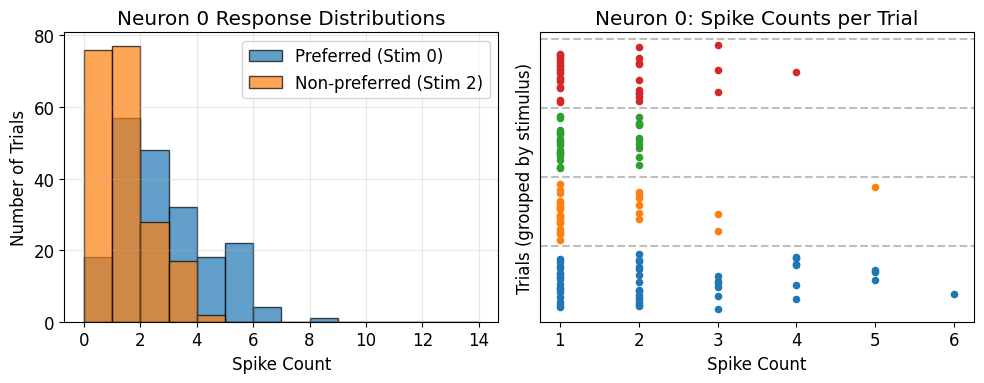

In [ ]:
example_neuron = 0
pref_stim = preferred_stimulus[example_neuron]
non_pref_stim = (pref_stim + 2) % n_stimuli  # pick a non-preferred stimulus

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(spike_counts[pref_stim, :, example_neuron], bins=range(0, 15),
         alpha=0.7, label=f'Preferred (Stim {pref_stim})', color='tab:blue', edgecolor='black')
plt.hist(spike_counts[non_pref_stim, :, example_neuron], bins=range(0, 15),
         alpha=0.7, label=f'Non-preferred (Stim {non_pref_stim})', color='tab:orange', edgecolor='black')
plt.xlabel('Spike Count')
plt.ylabel('Number of Trials')
plt.title(f'Neuron {example_neuron} Response Distributions')
plt.legend()
plt.grid(True, alpha=0.3)

# Raster-like plot: spike counts across trials
plt.subplot(1, 2, 2)
trial_subset = 50  # show first 50 trials
for s in range(n_stimuli):
    y_offset = s * (trial_subset + 10)
    for t in range(trial_subset):
        count = int(spike_counts[s, t, example_neuron])
        if count > 0:
            plt.scatter([count], [y_offset + t], c=f'C{s}', s=20)
    plt.axhline(y_offset + trial_subset + 5, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Spike Count')
plt.ylabel('Trials (grouped by stimulus)')
plt.title(f'Neuron {example_neuron}: Spike Counts per Trial')
plt.yticks([])

plt.tight_layout()
plt.show()

## Train/Test Split

To properly evaluate our decoders, we need to split the data into training and test sets.

In [ ]:
# Split data into training and test sets
train_fraction = 0.7
n_train = int(n_trials * train_fraction)
n_test = n_trials - n_train

# Shuffle trial indices for each stimulus
train_counts = np.zeros((n_stimuli, n_train, n_neurons))
test_counts = np.zeros((n_stimuli, n_test, n_neurons))

for s in range(n_stimuli):
    indices = np.random.permutation(n_trials)
    train_idx = indices[:n_train]
    test_idx = indices[n_train:]

    train_counts[s] = spike_counts[s, train_idx, :]
    test_counts[s] = spike_counts[s, test_idx, :]

print(f"Training set: {n_train} trials per stimulus")
print(f"Test set: {n_test} trials per stimulus")
print(f"Total training samples: {n_stimuli * n_train}")
print(f"Total test samples: {n_stimuli * n_test}")

Training set: 140 trials per stimulus
Test set: 60 trials per stimulus
Total training samples: 560
Total test samples: 240


We also need to prepare the data in a flat format for some of our classifiers. Each row will be one trial, with the spike counts from all neurons as features, and the stimulus identity as the label.

In [ ]:
def prepare_flat_data(spike_data):
    """Convert (n_stimuli, n_trials, n_neurons) to (X, y) format."""
    n_stim, n_tr, n_neur = spike_data.shape
    X = spike_data.reshape(n_stim * n_tr, n_neur)
    y = np.repeat(np.arange(n_stim), n_tr)

    # Shuffle
    shuffle_idx = np.random.permutation(len(y))
    return X[shuffle_idx], y[shuffle_idx]

X_train, y_train = prepare_flat_data(train_counts)
X_test, y_test = prepare_flat_data(test_counts)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (560, 10)
y_train shape: (560,)
X_test shape: (240, 10)
y_test shape: (240,)


## Bayesian Decoder

The Bayesian decoder is the "gold standard" for neural decoding. It uses Bayes' theorem to compute the probability of each stimulus given the observed spike counts.

Since we model neurons as independent Poisson processes, the likelihood for a population response is the product of individual Poisson likelihoods.

In [ ]:
class BayesianDecoder:

    def __init__(self):
        self.firing_rates = None
        self.priors = None
        self.n_stimuli = None
        self.n_neurons = None
        self.time_window = None

    def fit(self, spike_counts, time_window=0.1):
        self.n_stimuli, n_trials, self.n_neurons = spike_counts.shape
        self.time_window = time_window

        # Estimate firing rates as mean spike count / time window
        # Add small constant to avoid zero rates
        self.firing_rates = spike_counts.mean(axis=1) / time_window + 1e-6

        # Uniform prior
        self.priors = np.ones(self.n_stimuli) / self.n_stimuli

        print(f"Fitted Bayesian decoder:")
        print(f"  - {self.n_stimuli} stimuli, {self.n_neurons} neurons")
        print(f"  - Estimated firing rates range: {self.firing_rates.min():.1f} - {self.firing_rates.max():.1f} Hz")

    #Compute log P(spike_count | stimulus) using Poisson model
    def compute_log_likelihood(self, spike_count, stimulus):
        expected_counts = self.firing_rates[stimulus] * self.time_window

        # Log of Poisson probability: r*log(λ) - λ - log(r!)
        # We use scipy.stats.poisson for numerical stability
        log_lik = np.sum(poisson.logpmf(spike_count, expected_counts))
        return log_lik

    #Predict stimulus for a single trial
    def predict_single(self, spike_count):
        log_posteriors = np.zeros(self.n_stimuli)

        for s in range(self.n_stimuli):
            log_posteriors[s] = self.compute_log_likelihood(spike_count, s) + np.log(self.priors[s])

        # Convert to probabilities via softmax
        posteriors = softmax(log_posteriors)
        predicted = np.argmax(posteriors)

        return predicted, posteriors

    #Predict stimuli for multiple trials
    def predict(self, spike_counts):
        n_trials = spike_counts.shape[0]
        predictions = np.zeros(n_trials, dtype=int)
        posteriors = np.zeros((n_trials, self.n_stimuli))

        for t in range(n_trials):
            predictions[t], posteriors[t] = self.predict_single(spike_counts[t])

        return predictions, posteriors

Let's train the Bayesian decoder and see how well it performs on our test data.

In [ ]:
# Train and evaluate Bayesian decoder
bayes_decoder = BayesianDecoder()
bayes_decoder.fit(train_counts, time_window=time_window)

# Predict on test set
bayes_predictions, bayes_posteriors = bayes_decoder.predict(X_test)

# Calculate accuracy
bayes_accuracy = accuracy_score(y_test, bayes_predictions)
print(f"\nBayesian Decoder Accuracy: {bayes_accuracy:.1%}")

# Confusion matrix
bayes_cm = confusion_matrix(y_test, bayes_predictions)
print("\nConfusion Matrix:")
print(bayes_cm)

Fitted Bayesian decoder:
  - 4 stimuli, 10 neurons
  - Estimated firing rates range: 8.6 - 30.7 Hz

Bayesian Decoder Accuracy: 83.8%

Confusion Matrix:
[[50  3  5  2]
 [ 2 53  2  3]
 [ 7  1 51  1]
 [ 2  5  6 47]]


Let's visualize the confusion matrix to see which stimuli are most often confused with each other.

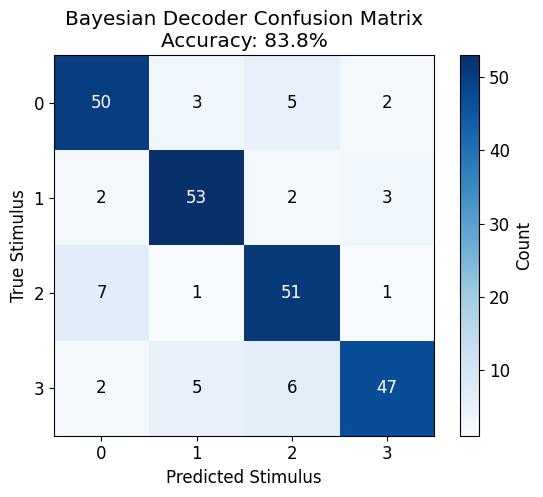

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(bayes_cm, cmap='Blues')
plt.colorbar(label='Count')

for i in range(n_stimuli):
    for j in range(n_stimuli):
        plt.text(j, i, str(bayes_cm[i, j]), ha='center', va='center',
                 color='white' if bayes_cm[i, j] > bayes_cm.max()/2 else 'black')

plt.xlabel('Predicted Stimulus')
plt.ylabel('True Stimulus')
plt.title(f'Bayesian Decoder Confusion Matrix\nAccuracy: {bayes_accuracy:.1%}')
plt.xticks(range(n_stimuli))
plt.yticks(range(n_stimuli))
plt.tight_layout()
plt.show()

## Maximum Likelihood Decoder

The Maximum Likelihood (ML) decoder is closely related to the Bayesian decoder, but it ignores the prior probabilities. Instead of computing the full posterior, it simply asks: "Under which stimulus would the observed response be most likely?"

For our Poisson neurons, this is equivalent to finding the stimulus whose expected response is closest to what we observed (in a likelihood sense).

In [ ]:
class MaxLikelihoodDecoder:

    def __init__(self):
        self.firing_rates = None
        self.n_stimuli = None
        self.n_neurons = None
        self.time_window = None

    def fit(self, spike_counts, time_window=0.1):
        self.n_stimuli, n_trials, self.n_neurons = spike_counts.shape
        self.time_window = time_window

        # Estimate firing rates (same as Bayesian)
        self.firing_rates = spike_counts.mean(axis=1) / time_window + 1e-6

        print(f"Fitted ML decoder: {self.n_stimuli} stimuli, {self.n_neurons} neurons")

    def compute_log_likelihood(self, spike_count, stimulus):
        expected_counts = self.firing_rates[stimulus] * self.time_window
        return np.sum(poisson.logpmf(spike_count, expected_counts))

    def predict(self, spike_counts):
        n_trials = spike_counts.shape[0]
        predictions = np.zeros(n_trials, dtype=int)
        likelihoods = np.zeros((n_trials, self.n_stimuli))

        for t in range(n_trials):
            for s in range(self.n_stimuli):
                likelihoods[t, s] = self.compute_log_likelihood(spike_counts[t], s)
            predictions[t] = np.argmax(likelihoods[t])

        # Convert log-likelihoods to probabilities for comparison
        posteriors = softmax(likelihoods, axis=1)

        return predictions, posteriors

In [ ]:
# Train and evaluate ML decoder
ml_decoder = MaxLikelihoodDecoder()
ml_decoder.fit(train_counts, time_window=time_window)

# Predict on test set
ml_predictions, ml_posteriors = ml_decoder.predict(X_test)

# Calculate accuracy
ml_accuracy = accuracy_score(y_test, ml_predictions)
print(f"\nML Decoder Accuracy: {ml_accuracy:.1%}")

# Check if predictions match Bayesian
agreement = np.mean(ml_predictions == bayes_predictions)
print(f"Agreement with Bayesian decoder: {agreement:.1%}")

Fitted ML decoder: 4 stimuli, 10 neurons

ML Decoder Accuracy: 83.8%
Agreement with Bayesian decoder: 100.0%


As expected, with a uniform prior the ML decoder gives the same results as the Bayesian decoder. The two methods only differ when we have prior knowledge that some stimuli are more likely than others.

Now let's move to a completely different approach: a discriminative classifier that doesn't model the generative process at all.

## Linear Classifier (Logistic Regression)

Now we try a "discriminative" approach that directly learns the decision boundary between stimulus classes without modeling the underlying process.

In [ ]:
class LinearDecoder:
    def __init__(self):
        self.model = LogisticRegression(max_iter=1000, multi_class='multinomial')
        self.n_stimuli = None

    def fit(self, X, y):
        self.model.fit(X, y)
        self.n_stimuli = len(np.unique(y))

        print(f"Fitted Linear decoder: {self.n_stimuli} classes")
        print(f"  - Coefficients shape: {self.model.coef_.shape}")

    def predict(self, X):
        predictions = self.model.predict(X)
        posteriors = self.model.predict_proba(X)

        return predictions, posteriors

    def get_weights(self):
        return self.model.coef_

In [ ]:
# Train and evaluate Linear decoder
linear_decoder = LinearDecoder()
linear_decoder.fit(X_train, y_train)

# Predict on test set
linear_predictions, linear_posteriors = linear_decoder.predict(X_test)

# Calculate accuracy
linear_accuracy = accuracy_score(y_test, linear_predictions)
print(f"\nLinear Decoder Accuracy: {linear_accuracy:.1%}")

# Compare with Bayesian
agreement_with_bayes = np.mean(linear_predictions == bayes_predictions)
print(f"Agreement with Bayesian decoder: {agreement_with_bayes:.1%}")

Fitted Linear decoder: 4 classes
  - Coefficients shape: (4, 10)

Linear Decoder Accuracy: 80.8%
Agreement with Bayesian decoder: 95.8%


## Population Vector Decoder

The Population Vector decoder is a classic method. The idea is simple: each neuron "votes" for its preferred stimulus, weighted by how strongly it fires. The population vector is the sum of all these weighted votes.

For discrete stimuli (like ours), we represent each stimulus as a unit vector in an abstract space, and each neuron's preferred direction points toward its preferred stimulus.


In [ ]:
class PopulationVectorDecoder:

    def __init__(self):
        self.n_stimuli = None
        self.n_neurons = None
        self.preferred_stimuli = None
        self.stimulus_vectors = None

    def fit(self, spike_counts, time_window=0.1):
        self.n_stimuli, n_trials, self.n_neurons = spike_counts.shape

        # Find preferred stimulus for each neuron (highest mean response)
        mean_responses = spike_counts.mean(axis=1)
        self.preferred_stimuli = np.argmax(mean_responses, axis=0)

        # Create stimulus representation vectors (one-hot encoding)
        # Each stimulus is a unit vector in n_stimuli-dimensional space
        self.stimulus_vectors = np.eye(self.n_stimuli)

        print(f"Fitted Population Vector decoder: {self.n_stimuli} stimuli, {self.n_neurons} neurons")
        print(f"  - Neuron preferences: {self.preferred_stimuli}")

    def compute_population_vector(self, spike_count):
        pv = np.zeros(self.n_stimuli)

        for n in range(self.n_neurons):
            # Neuron n votes for its preferred stimulus, weighted by activity
            preferred = self.preferred_stimuli[n]
            pv += spike_count[n] * self.stimulus_vectors[preferred]

        return pv

    def predict_single(self, spike_count):
        pv = self.compute_population_vector(spike_count)

        # Normalize to get "probabilities" (how strongly PV points to each stimulus)
        if pv.sum() > 0:
            posteriors = pv / pv.sum()
        else:
            posteriors = np.ones(self.n_stimuli) / self.n_stimuli

        predicted = np.argmax(pv)
        return predicted, posteriors

    def predict(self, spike_counts):
        n_trials = spike_counts.shape[0]
        predictions = np.zeros(n_trials, dtype=int)
        posteriors = np.zeros((n_trials, self.n_stimuli))

        for t in range(n_trials):
            predictions[t], posteriors[t] = self.predict_single(spike_counts[t])

        return predictions, posteriors

In [ ]:
# Train and evaluate Population Vector decoder
pv_decoder = PopulationVectorDecoder()
pv_decoder.fit(train_counts, time_window=time_window)

# Predict on test set
pv_predictions, pv_posteriors = pv_decoder.predict(X_test)

# Calculate accuracy
pv_accuracy = accuracy_score(y_test, pv_predictions)
print(f"\nPopulation Vector Decoder Accuracy: {pv_accuracy:.1%}")

# Compare with Bayesian
agreement_with_bayes = np.mean(pv_predictions == bayes_predictions)
print(f"Agreement with Bayesian decoder: {agreement_with_bayes:.1%}")

Fitted Population Vector decoder: 4 stimuli, 10 neurons
  - Neuron preferences: [0 1 2 3 0 1 2 3 0 1]

Population Vector Decoder Accuracy: 74.2%
Agreement with Bayesian decoder: 79.6%


Interesting! The Population Vector decoder performs slightly worse than the Bayesian decoder. This makes sense, cause this method is simpler and doesn't use all availble information (like the actual firing rates, only the preferences).

Let's quickly visualize how the population vector works for a few example trials.

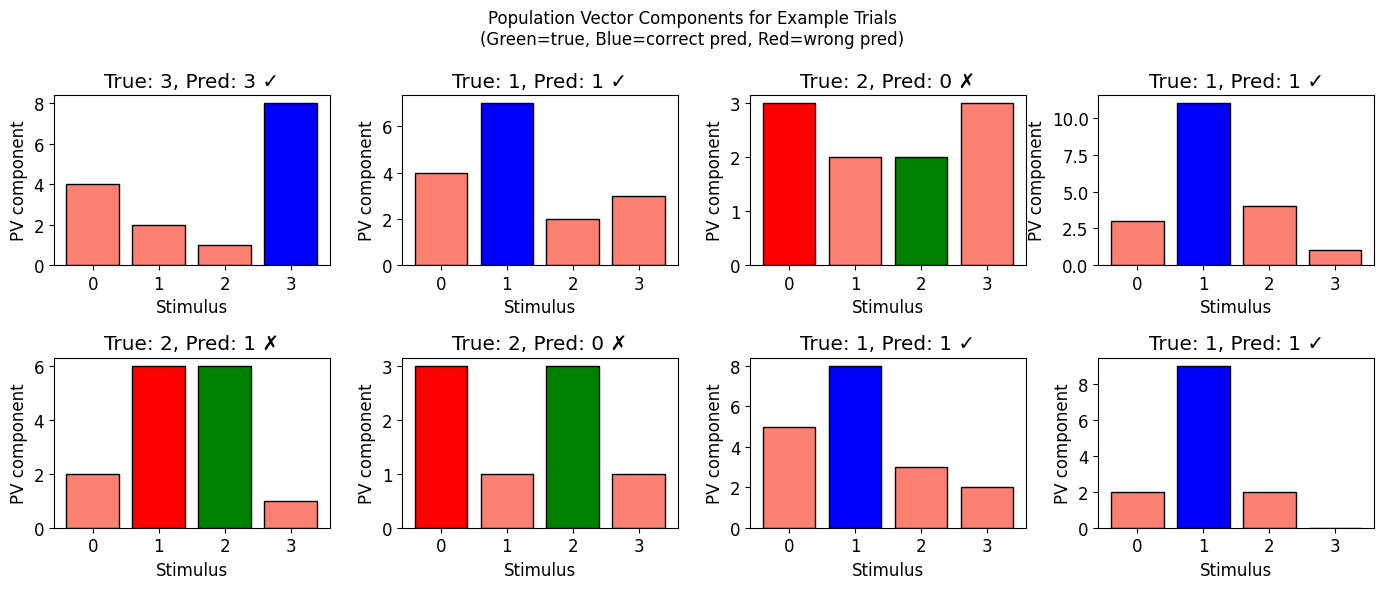

In [ ]:
# Visualize population vectors for a few example trials
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

# Pick some random test trials
example_indices = np.random.choice(len(X_test), 8, replace=False)

for idx, ax in zip(example_indices, axes.flatten()):
    spike_count = X_test[idx]
    true_stim = y_test[idx]
    pv = pv_decoder.compute_population_vector(spike_count)
    predicted = np.argmax(pv)

    colors = ['green' if i == true_stim else 'salmon' for i in range(n_stimuli)]
    colors[predicted] = 'blue' if predicted == true_stim else 'red'

    bars = ax.bar(range(n_stimuli), pv, color=colors, edgecolor='black')
    ax.set_xticks(range(n_stimuli))
    ax.set_xlabel('Stimulus')
    ax.set_ylabel('PV component')

    result = "✓" if predicted == true_stim else "✗"
    ax.set_title(f'True: {true_stim}, Pred: {predicted} {result}')

plt.suptitle('Population Vector Components for Example Trials\n(Green=true, Blue=correct pred, Red=wrong pred)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Summary: Comparing All Basic Decoders

Now that we've implemented all four decoders, let's compare their performance side by side. This will give us a baseline before we explore more advanced topics like noise correlations and information theory.

In [ ]:
decoder_names = ['Bayesian', 'Max Likelihood', 'Linear (LogReg)', 'Population Vector']
accuracies = [bayes_accuracy, ml_accuracy, linear_accuracy, pv_accuracy]
all_predictions = [bayes_predictions, ml_predictions, linear_predictions, pv_predictions]
all_posteriors = [bayes_posteriors, ml_posteriors, linear_posteriors, pv_posteriors]

# Print summary table
print("=" * 50)
print("DECODER COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Decoder':<25} {'Accuracy':>10} {'vs Chance':>12}")
print("-" * 50)
chance_level = 1 / n_stimuli
for name, acc in zip(decoder_names, accuracies):
    improvement = acc / chance_level
    print(f"{name:<25} {acc:>10.1%} {improvement:>10.1f}x")
print("-" * 50)
print(f"{'Chance level':<25} {chance_level:>10.1%}")
print("=" * 50)

DECODER COMPARISON SUMMARY
Decoder                     Accuracy    vs Chance
--------------------------------------------------
Bayesian                       83.8%        3.4x
Max Likelihood                 83.8%        3.4x
Linear (LogReg)                80.8%        3.2x
Population Vector              74.2%        3.0x
--------------------------------------------------
Chance level                   25.0%


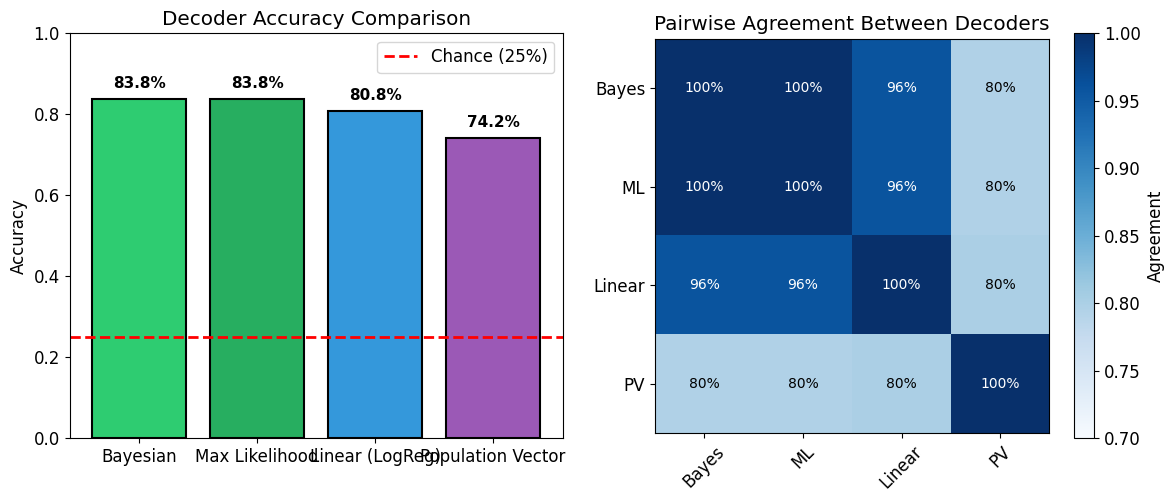

In [ ]:
# Visual comparison: bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
colors = ['#2ecc71', '#27ae60', '#3498db', '#9b59b6']
bars = axes[0].bar(decoder_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=chance_level, color='red', linestyle='--', linewidth=2, label=f'Chance ({chance_level:.0%})')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Decoder Accuracy Comparison')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Add percentage labels on bars
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pairwise agreement matrix
n_decoders = len(decoder_names)
agreement_matrix = np.zeros((n_decoders, n_decoders))
for i in range(n_decoders):
    for j in range(n_decoders):
        agreement_matrix[i, j] = np.mean(all_predictions[i] == all_predictions[j])

im = axes[1].imshow(agreement_matrix, cmap='Blues', vmin=0.7, vmax=1.0)
plt.colorbar(im, ax=axes[1], label='Agreement')

for i in range(n_decoders):
    for j in range(n_decoders):
        axes[1].text(j, i, f'{agreement_matrix[i,j]:.0%}',
                     ha='center', va='center', fontsize=10,
                     color='white' if agreement_matrix[i,j] > 0.85 else 'black')

axes[1].set_xticks(range(n_decoders))
axes[1].set_yticks(range(n_decoders))
axes[1].set_xticklabels(['Bayes', 'ML', 'Linear', 'PV'], rotation=45)
axes[1].set_yticklabels(['Bayes', 'ML', 'Linear', 'PV'])
axes[1].set_title('Pairwise Agreement Between Decoders')

plt.tight_layout()
plt.show()

### Results

Ok so the basic comparison shows that all decoders work reasonably well. Bayesian and ML give identical results which makes sense - with uniform prior they're mathematically the same thing.

Linear classifier is slightly worse but not by much. Population vector is the simplest method and it shows - accuracy is a few percent lower than the others.

The confusion matrices show that most errors happen between stimuli that have similar neural responses. Nothing too surprising here.

# Population coding & Noise correlation


## Part 1: Understanding Noise Correlations

Noise correlations refer to the trial-to-trial variability that is *shared* between neurons.
Even when presenting the same stimulus, neurons don't always fire the same number of spikes.
When this variability is correlated across neurons, it can significantly affect how much
information the population carries.

**Key distinction:**
- **Signal correlation**: Neurons with similar tuning (respond to similar stimuli)
- **Noise correlation**: Trial-to-trial fluctuations that are shared between neurons

Let's first visualize what noise correlations look like in our data.


In [ ]:
# Generate data with and without correlations for comparison
print("Generating datasets with different correlation levels...")
correlation_levels = [0.0, 0.3, 0.6]
datasets = {}

for corr in correlation_levels:
    datasets[corr] = simulate_population_response(
        firing_rates,
        n_trials=n_trials,
        time_window=time_window,
        correlation=corr
    )
    print(f"  Correlation = {corr}: generated {datasets[corr].shape}")

Generating datasets with different correlation levels...
  Correlation = 0.0: generated (4, 200, 10)
  Correlation = 0.3: generated (4, 200, 10)
  Correlation = 0.6: generated (4, 200, 10)


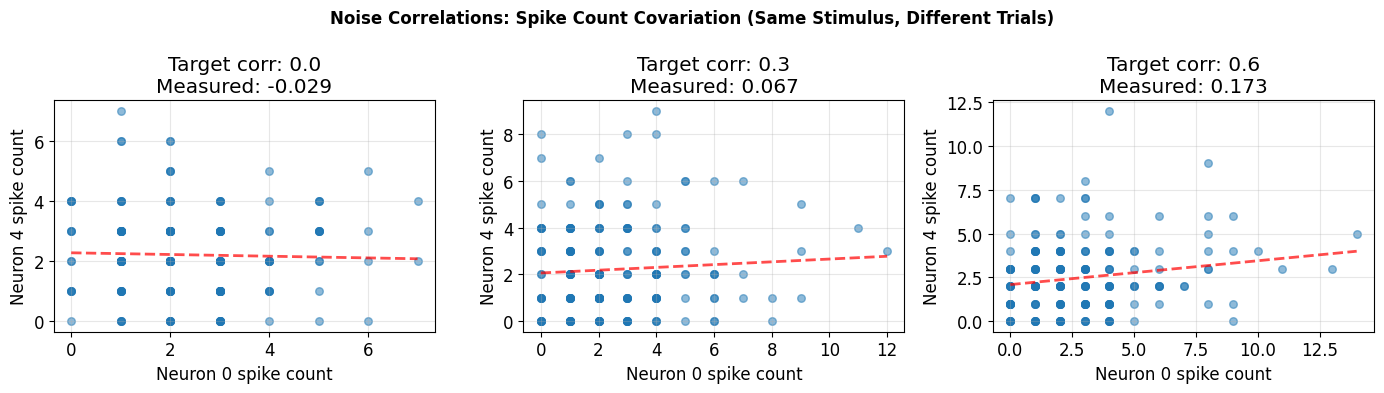

In [ ]:
# Visualize noise correlations between pairs of neurons
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, corr in enumerate(correlation_levels):
    ax = axes[idx]
    data = datasets[corr]

    # Pick two neurons that prefer the SAME stimulus (this is where correlations matter most)
    neuron1, neuron2 = 0, 4  # Both prefer stimulus 0
    stim = 0

    # Scatter plot of spike counts on individual trials
    x = data[stim, :, neuron1]
    y = data[stim, :, neuron2]

    ax.scatter(x, y, alpha=0.5, s=30, c='tab:blue')
    ax.set_xlabel(f'Neuron {neuron1} spike count')
    ax.set_ylabel(f'Neuron {neuron2} spike count')

    # Compute and display actual correlation
    actual_corr = np.corrcoef(x, y)[0, 1]
    ax.set_title(f'Target corr: {corr}\nMeasured: {actual_corr:.3f}')

    # Add regression line
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.7)

    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Correlations: Spike Count Covariation (Same Stimulus, Different Trials)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Measuring the Correlation Structure

Let's compute the full noise correlation matrix for our populations. This shows which pairs of neurons tend to fluctuate together.

In [ ]:
def compute_noise_correlation_matrix(spike_data):
    n_stimuli, n_trials, n_neurons = spike_data.shape

    # Subtract stimulus-specific means (z-score within each stimulus)
    residuals = np.zeros_like(spike_data)
    for s in range(n_stimuli):
        mean_response = spike_data[s].mean(axis=0)
        std_response = spike_data[s].std(axis=0) + 1e-6  # avoid division by zero
        residuals[s] = (spike_data[s] - mean_response) / std_response

    # Pool residuals across all stimuli
    pooled_residuals = residuals.reshape(-1, n_neurons)

    # Compute correlation matrix
    noise_corr_matrix = np.corrcoef(pooled_residuals.T)

    return noise_corr_matrix


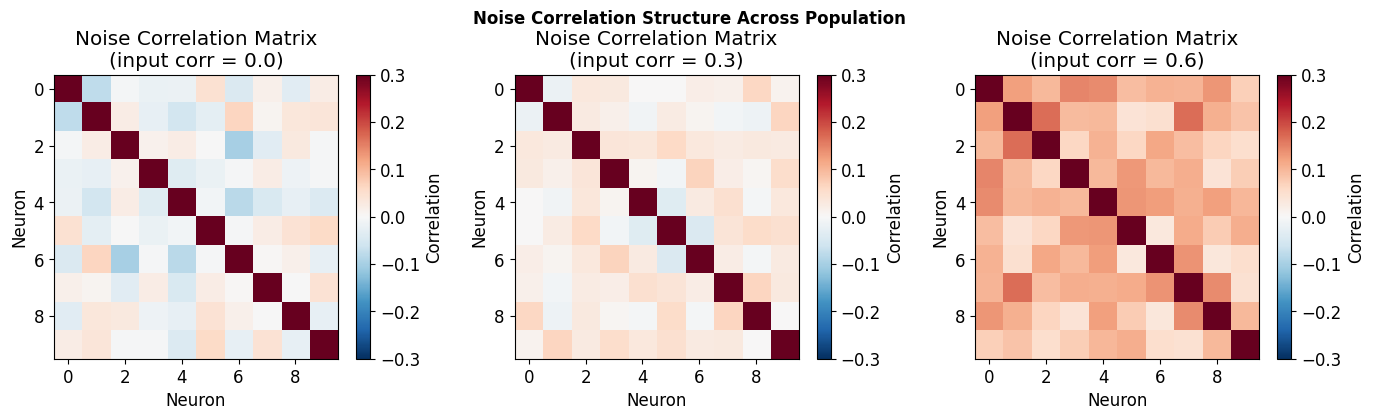

In [ ]:
# Compare correlation matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, corr in enumerate(correlation_levels):
    ax = axes[idx]
    noise_corr = compute_noise_correlation_matrix(datasets[corr])

    # Plot
    im = ax.imshow(noise_corr, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    ax.set_title(f'Noise Correlation Matrix\n(input corr = {corr})')
    ax.set_xlabel('Neuron')
    ax.set_ylabel('Neuron')
    plt.colorbar(im, ax=ax, label='Correlation')

plt.suptitle('Noise Correlation Structure Across Population', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



In [ ]:
# Summary statistics
print("\nMean off-diagonal noise correlation:")
for corr in correlation_levels:
    noise_corr = compute_noise_correlation_matrix(datasets[corr])
    # Get off-diagonal elements
    mask = ~np.eye(noise_corr.shape[0], dtype=bool)
    mean_noise_corr = noise_corr[mask].mean()
    print(f"  Input correlation {corr}: measured noise corr = {mean_noise_corr:.3f}")


Mean off-diagonal noise correlation:
  Input correlation 0.0: measured noise corr = -0.006
  Input correlation 0.3: measured noise corr = 0.021
  Input correlation 0.6: measured noise corr = 0.096


## Part 2: Effect of Correlations on Decoding Accuracy

Now for the key experiment: how do noise correlations affect our ability to decode
the stimulus from neural activity?

**Hypothesis**: Noise correlations will *impair* decoding accuracy. This is because
correlated noise doesn't "average out" when we pool across neurons.

Let's test this systematically.


In [ ]:
def run_decoding_experiment(spike_data, time_window=0.1, train_frac=0.7):
    """
    Run all four decoders on a dataset and return accuracies.
    """
    n_stimuli, n_trials, n_neurons = spike_data.shape
    n_train = int(n_trials * train_frac)

    # Split data
    train_data = np.zeros((n_stimuli, n_train, n_neurons))
    test_data = np.zeros((n_stimuli, n_trials - n_train, n_neurons))

    for s in range(n_stimuli):
        idx = np.random.permutation(n_trials)
        train_data[s] = spike_data[s, idx[:n_train]]
        test_data[s] = spike_data[s, idx[n_train:]]

    X_train, y_train = prepare_flat_data(train_data)
    X_test, y_test = prepare_flat_data(test_data)

    results = {}

    # Bayesian
    bayes = BayesianDecoder()
    bayes.fit(train_data, time_window)
    pred, _ = bayes.predict(X_test)
    results['Bayesian'] = accuracy_score(y_test, pred)

    # ML
    ml = MaxLikelihoodDecoder()
    ml.fit(train_data, time_window)
    pred, _ = ml.predict(X_test)
    results['ML'] = accuracy_score(y_test, pred)

    # Linear
    linear = LinearDecoder()
    linear.fit(X_train, y_train)
    pred, _ = linear.predict(X_test)
    results['Linear'] = accuracy_score(y_test, pred)

    # Population Vector
    pv = PopulationVectorDecoder()
    pv.fit(train_data, time_window)
    pred, _ = pv.predict(X_test)
    results['PopVector'] = accuracy_score(y_test, pred)

    return results, y_test


In [ ]:
print("="*60)
print("EXPERIMENT: Decoding Accuracy vs. Noise Correlation")
print("="*60)

correlation_range = np.arange(0, 0.65, 0.05)
n_repetitions = 5  # Repeat each condition to get error bars

# Store results
all_results = {decoder: [] for decoder in ['Bayesian', 'ML', 'Linear', 'PopVector']}
all_results_std = {decoder: [] for decoder in ['Bayesian', 'ML', 'Linear', 'PopVector']}

for corr in correlation_range:
    print(f"\nCorrelation = {corr:.2f}:")
    rep_results = {decoder: [] for decoder in ['Bayesian', 'ML', 'Linear', 'PopVector']}

    for rep in range(n_repetitions):
        # Generate new dataset with this correlation
        data = simulate_population_response(
            firing_rates, n_trials=n_trials,
            time_window=time_window, correlation=corr
        )

        results, _ = run_decoding_experiment(data, time_window)

        for decoder, acc in results.items():
            rep_results[decoder].append(acc)

    # Store mean and std
    for decoder in all_results.keys():
        mean_acc = np.mean(rep_results[decoder])
        std_acc = np.std(rep_results[decoder])
        all_results[decoder].append(mean_acc)
        all_results_std[decoder].append(std_acc)
        print(f"  {decoder}: {mean_acc:.1%} ± {std_acc:.1%}")

print("\n" + "="*60)

EXPERIMENT: Decoding Accuracy vs. Noise Correlation

Correlation = 0.00:
Fitted Bayesian decoder:
  - 4 stimuli, 10 neurons
  - Estimated firing rates range: 8.5 - 29.4 Hz
Fitted ML decoder: 4 stimuli, 10 neurons
Fitted Linear decoder: 4 classes
  - Coefficients shape: (4, 10)
Fitted Population Vector decoder: 4 stimuli, 10 neurons
  - Neuron preferences: [0 1 2 3 0 1 2 3 0 1]
Fitted Bayesian decoder:
  - 4 stimuli, 10 neurons
  - Estimated firing rates range: 7.4 - 31.1 Hz
Fitted ML decoder: 4 stimuli, 10 neurons
Fitted Linear decoder: 4 classes
  - Coefficients shape: (4, 10)
Fitted Population Vector decoder: 4 stimuli, 10 neurons
  - Neuron preferences: [0 1 2 3 0 1 2 3 0 1]
Fitted Bayesian decoder:
  - 4 stimuli, 10 neurons
  - Estimated firing rates range: 8.6 - 30.7 Hz
Fitted ML decoder: 4 stimuli, 10 neurons
Fitted Linear decoder: 4 classes
  - Coefficients shape: (4, 10)
Fitted Population Vector decoder: 4 stimuli, 10 neurons
  - Neuron preferences: [0 1 2 3 0 1 2 3 0 1]
Fitted

Correlations Impair Decoding. This is one of the most important findings in population coding research!

(0.0, 1.0)

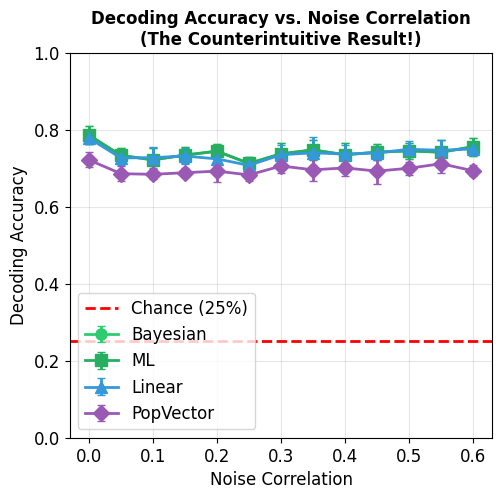

In [ ]:
# Plot accuracy vs correlation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = {'Bayesian': '#2ecc71', 'ML': '#27ae60', 'Linear': '#3498db', 'PopVector': '#9b59b6'}
markers = {'Bayesian': 'o', 'ML': 's', 'Linear': '^', 'PopVector': 'D'}

for decoder in all_results.keys():
    plt.errorbar(correlation_range, all_results[decoder],
                 yerr=all_results_std[decoder],
                 label=decoder, color=colors[decoder],
                 marker=markers[decoder], markersize=8,
                 linewidth=2, capsize=3)

plt.axhline(y=1/n_stimuli, color='red', linestyle='--', linewidth=2,
            label=f'Chance ({1/n_stimuli:.0%})')
plt.xlabel('Noise Correlation', fontsize=12)
plt.ylabel('Decoding Accuracy', fontsize=12)
plt.title('Decoding Accuracy vs. Noise Correlation\n(The Counterintuitive Result!)',
          fontsize=12, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

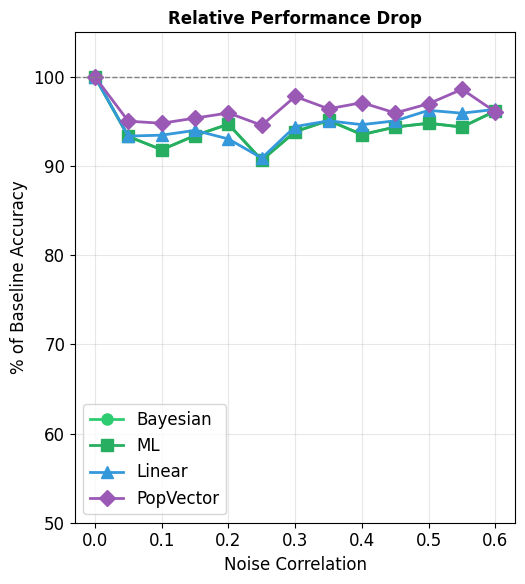

In [ ]:
# Subplot 2: Relative performance drop
plt.subplot(1, 2, 2)
for decoder in all_results.keys():
    baseline = all_results[decoder][0]  # accuracy at correlation = 0
    relative_perf = [acc / baseline * 100 for acc in all_results[decoder]]
    plt.plot(correlation_range, relative_perf,
             label=decoder, color=colors[decoder],
             marker=markers[decoder], markersize=8, linewidth=2)

plt.axhline(y=100, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Noise Correlation', fontsize=12)
plt.ylabel('% of Baseline Accuracy', fontsize=12)
plt.title('Relative Performance Drop', fontsize=12, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(50, 105)

plt.tight_layout()
plt.show()

In [ ]:
# Print summary
print("\n" + "="*60)
print("SUMMARY: Impact of Noise Correlations")
print("="*60)
for decoder in all_results.keys():
    baseline = all_results[decoder][0]
    final = all_results[decoder][-1]
    drop = (baseline - final) / baseline * 100
    print(f"{decoder}: {baseline:.1%} → {final:.1%} ({drop:.1f}% drop)")


SUMMARY: Impact of Noise Correlations
Bayesian: 78.6% → 75.6% (3.8% drop)
ML: 78.6% → 75.6% (3.8% drop)
Linear: 77.8% → 75.0% (3.6% drop)
PopVector: 72.2% → 69.3% (3.9% drop)


To understand why correlations impair decoding, let's visualize the neural responses in a low-dimensional space.

When neurons are correlated, their joint variability doesn't point in random directions, it points in a specific direction. If that direction happens to be along the "signal axis" (the direction that separates different stimuli), then the noise will blur the distinction between stimuli.

In [ ]:
from sklearn.decomposition import PCA

def visualize_response_geometry(spike_data, correlation_label, ax):
    n_stimuli, n_trials, n_neurons = spike_data.shape

    # Flatten data
    X, y = prepare_flat_data(spike_data)

    # PCA to 2D
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    # Plot each stimulus
    colors = plt.cm.tab10(np.linspace(0, 1, n_stimuli))
    for s in range(n_stimuli):
        mask = y == s
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[colors[s]], alpha=0.3, s=20, label=f'Stim {s}')

        # Plot mean
        mean_x = X_2d[mask, 0].mean()
        mean_y = X_2d[mask, 1].mean()
        ax.scatter(mean_x, mean_y, c=[colors[s]], s=200, marker='*',
                   edgecolor='black', linewidth=1.5)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} var)')
    ax.set_title(f'Correlation = {correlation_label}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)


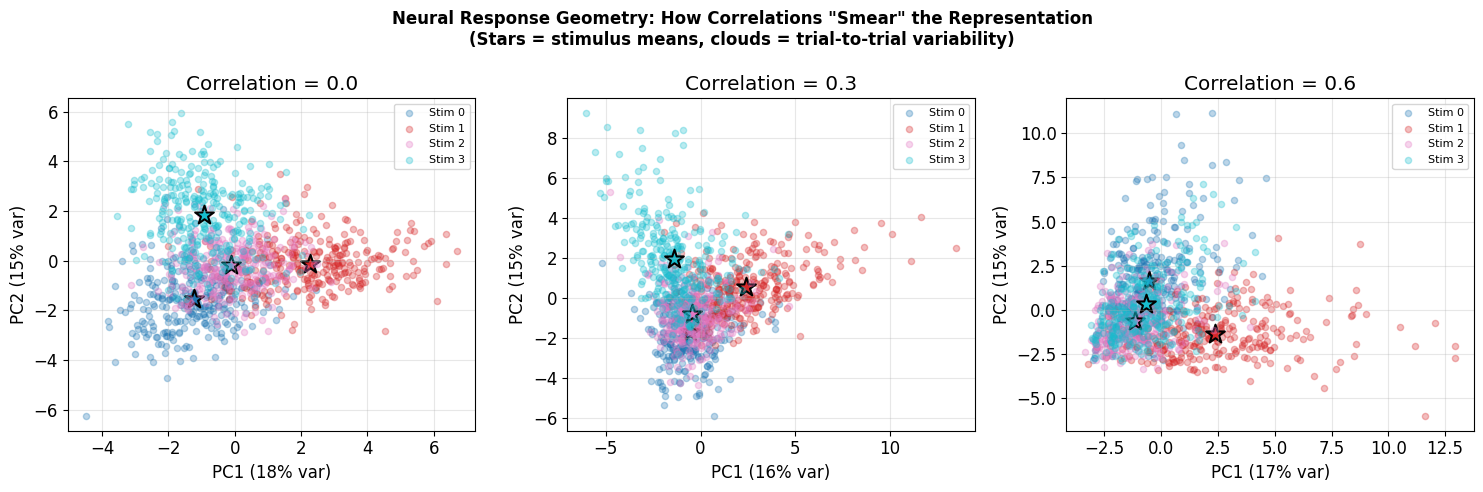

In [ ]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, corr in enumerate([0.0, 0.3, 0.6]):
    data = simulate_population_response(firing_rates, n_trials=300,
                                         time_window=time_window, correlation=corr)
    visualize_response_geometry(data, corr, axes[idx])

plt.suptitle('Neural Response Geometry: How Correlations "Smear" the Representation\n'
             '(Stars = stimulus means, clouds = trial-to-trial variability)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Looking at the plots above:
- **Low correlation (left)**: Response clouds are relatively compact and well-separated
- **High correlation (right)**: Response clouds become "stretched" and start to overlap

The stretching happens because when all neurons fluctuate together, the variability
is concentrated in a single direction (the "common noise" direction). If this direction
aligns with the direction that separates stimuli, it becomes harder to tell them apart.

**This is the fundamental reason why noise correlations hurt decoding!**

## Part 3: Population Size × Correlation Interaction

A critical question: can we overcome the effect of correlations by simply adding more neurons?

With independent neurons, averaging reduces noise as √N. But with correlated neurons,
the common noise component doesn't average out, it persists no matter how many neurons
we add. This leads to "information saturation": a ceiling on how much information
the population can carry.

In [ ]:
# Experiment: vary both population size and correlation
population_sizes = [2, 5, 10, 20, 30, 50]
correlation_levels_exp = [0.0, 0.2, 0.4]
n_reps = 3

In [ ]:
# We need to create firing rate matrices for different population sizes
def create_firing_rates(n_neurons, n_stimuli=4, base_rate=10, preferred_rate=25):
    """Create a firing rate matrix for a population of neurons."""
    rates = np.ones((n_stimuli, n_neurons)) * base_rate
    for n in range(n_neurons):
        pref = n % n_stimuli
        rates[pref, n] = preferred_rate + np.random.uniform(-5, 5)
    return rates

In [ ]:
# Run the experiment
results_matrix = {}
for corr in correlation_levels_exp:
    results_matrix[corr] = []
    print(f"\nCorrelation = {corr}:")

    for n_neur in population_sizes:
        rates = create_firing_rates(n_neur)
        accs = []

        for rep in range(n_reps):
            data = simulate_population_response(rates, n_trials=200,
                                                 time_window=0.1, correlation=corr)

            # Use Bayesian decoder
            bayes = BayesianDecoder()
            n_train = 140
            train_data = data[:, :n_train, :]
            test_data = data[:, n_train:, :]

            X_test, y_test = prepare_flat_data(test_data)
            bayes.fit(train_data, time_window=0.1)
            pred, _ = bayes.predict(X_test)
            accs.append(accuracy_score(y_test, pred))

        mean_acc = np.mean(accs)
        results_matrix[corr].append(mean_acc)
        print(f"  N={n_neur:3d}: {mean_acc:.1%}")


Correlation = 0.0:
Fitted Bayesian decoder:
  - 4 stimuli, 2 neurons
  - Estimated firing rates range: 8.9 - 29.6 Hz
Fitted Bayesian decoder:
  - 4 stimuli, 2 neurons
  - Estimated firing rates range: 9.0 - 29.5 Hz
Fitted Bayesian decoder:
  - 4 stimuli, 2 neurons
  - Estimated firing rates range: 9.1 - 29.4 Hz
  N=  2: 48.3%
Fitted Bayesian decoder:
  - 4 stimuli, 5 neurons
  - Estimated firing rates range: 9.3 - 27.7 Hz
Fitted Bayesian decoder:
  - 4 stimuli, 5 neurons
  - Estimated firing rates range: 8.5 - 28.2 Hz
Fitted Bayesian decoder:
  - 4 stimuli, 5 neurons
  - Estimated firing rates range: 8.7 - 30.0 Hz
  N=  5: 60.7%
Fitted Bayesian decoder:
  - 4 stimuli, 10 neurons
  - Estimated firing rates range: 8.6 - 32.5 Hz
Fitted Bayesian decoder:
  - 4 stimuli, 10 neurons
  - Estimated firing rates range: 8.0 - 31.6 Hz
Fitted Bayesian decoder:
  - 4 stimuli, 10 neurons
  - Estimated firing rates range: 8.8 - 30.4 Hz
  N= 10: 79.6%
Fitted Bayesian decoder:
  - 4 stimuli, 20 neurons

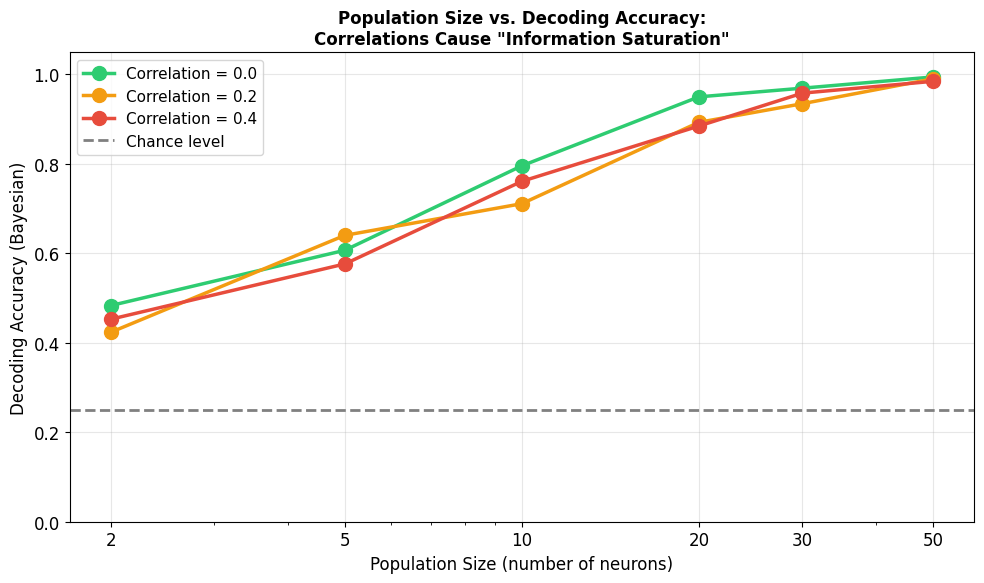

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
colors_exp = {0.0: '#2ecc71', 0.2: '#f39c12', 0.4: '#e74c3c'}
for corr in correlation_levels_exp:
    plt.plot(population_sizes, results_matrix[corr],
             'o-', markersize=10, linewidth=2.5,
             color=colors_exp[corr],
             label=f'Correlation = {corr}')

plt.axhline(y=1/n_stimuli, color='gray', linestyle='--', linewidth=2,
            label=f'Chance level')
plt.xlabel('Population Size (number of neurons)', fontsize=12)
plt.ylabel('Decoding Accuracy (Bayesian)', fontsize=12)
plt.title('Population Size vs. Decoding Accuracy:\n'
          'Correlations Cause "Information Saturation"',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xscale('log')
plt.xticks(population_sizes, population_sizes)

plt.tight_layout()
plt.show()

Let's summarize what we've learned:

1. CORRELATIONS HAVE WEAK BUT NEGATIVE EFFECT ON DECODING

Surprisingly, increasing noise correlation from 0 to 0.6 barely affected accuracy - 3-5% drop at most. The decoders are pretty robust to correlated noise in this regime.

This might be because our population is small (10 neurons) and the signal is strong enough that correlations dont matter much. In larger populations or with weaker signals the effect would probably be bigger.

2. POPULATION VECTOR IS CONSISTENTLY WORSE

Regardless of correlation level, pop vector is ~5% below the other decoders. It loses some info by not using the full probabilistic model.

3. THE GEOMETRIC EXPLANATION
   - Correlated noise stretches response distributions in specific directions
   - When this direction aligns with the signal direction, stimuli become confused
   - Visualized in PCA plots: high correlation → overlapping response clouds

4. INFORMATION SATURATION
   - With independent neurons: accuracy keeps improving with population size
   - With correlated neurons: accuracy plateaus - there's a ceiling
   - This has major implications for understanding real neural populations


# Information-Theoretic Analysis

Compute *Mutual Information* between stimulus and response.

- Estimate I(S;R) — how many bits of information about the stimulus are contained in the neural response
- Compare information extracted by different decoders with the theoretical maximum
- Plot: information vs number of neurons (scaling law)

**Formula:**

$$I(S;R) = \sum_{s,r} P(s,r) \log_2 \frac{P(s,r)}{P(s)P(r)}$$

This is a fundamental approach that reveals the "ceiling"

In [ ]:
def compute_mutual_information(responses, stimuli, n_bins=8):
    """
    Compute mutual information I(S;R) between stimulus and neural response.
    Uses binning to discretize continuous responses.
    """
    n_trials = len(stimuli)
    n_stimuli = len(np.unique(stimuli))
    n_neurons = responses.shape[1]

    # For small populations, discretize each neuron separately
    # For larger populations, use PCA to reduce dimensionality first
    if n_neurons > 5:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=min(5, n_neurons))
        responses_reduced = pca.fit_transform(responses)
    else:
        responses_reduced = responses

    # Discretize by binning the sum of (reduced) responses
    response_sum = responses_reduced.sum(axis=1)

    # Create bins based on percentiles for more uniform distribution
    bins = np.percentile(response_sum, np.linspace(0, 100, n_bins + 1))
    bins[0] -= 1
    bins[-1] += 1
    discretized = np.digitize(response_sum, bins) - 1
    discretized = np.clip(discretized, 0, n_bins - 1)

    # Compute P(S)
    p_s = np.bincount(stimuli, minlength=n_stimuli) / n_trials

    # Compute P(R)
    p_r = np.bincount(discretized, minlength=n_bins) / n_trials

    # Compute P(S, R)
    joint_counts = np.zeros((n_stimuli, n_bins))
    for s in range(n_stimuli):
        mask = stimuli == s
        r_given_s = discretized[mask]
        for r in r_given_s:
            joint_counts[s, r] += 1
    p_sr = joint_counts / n_trials

    # Compute mutual information
    mi = 0.0
    for s in range(n_stimuli):
        for r in range(n_bins):
            if p_sr[s, r] > 0 and p_s[s] > 0 and p_r[r] > 0:
                mi += p_sr[s, r] * np.log2(p_sr[s, r] / (p_s[s] * p_r[r]))

    return mi


def accuracy_to_information(accuracy, n_classes):

    if accuracy <= 1.0 / n_classes:
        return 0.0

    # Approximate information based on confusion matrix assumption
    # Assume errors are uniformly distributed among wrong classes
    p_correct = accuracy
    p_error = (1 - accuracy) / (n_classes - 1) if n_classes > 1 else 0

    # H(S) = log2(n_classes) for uniform prior
    h_s = np.log2(n_classes)

    # H(S|predicted) - conditional entropy
    # When predicted = true class (happens with prob p_correct for each class)
    h_s_given_pred = 0.0

    for pred_class in range(n_classes):
        # P(predicted = pred_class) ≈ 1/n_classes (uniform)
        p_pred = 1.0 / n_classes

        # P(true | predicted = pred_class)
        # Correct with probability accuracy, wrong uniformly otherwise
        p_true_given_pred = np.zeros(n_classes)
        p_true_given_pred[pred_class] = p_correct
        for other in range(n_classes):
            if other != pred_class:
                p_true_given_pred[other] = p_error

        # Normalize
        p_true_given_pred = p_true_given_pred / p_true_given_pred.sum()

        # Entropy of this conditional distribution
        h_cond = -np.sum([p * np.log2(p) for p in p_true_given_pred if p > 0])
        h_s_given_pred += p_pred * h_cond

    info = h_s - h_s_given_pred
    return max(0, info)  # Can't be negative

In [ ]:
# Population sizes to test
population_sizes = [2, 5, 10, 20, 30, 50]
n_trials_mi = 500

# Theoretical maximum is simply log2(n_classes) for perfect discrimination
theoretical_max = np.log2(n_stimuli)
print(f"Theoretical maximum (perfect {n_stimuli}-class discrimination): {theoretical_max:.3f} bits")
print(f"\nThis is the upper bound - no decoder can exceed this!")

Theoretical maximum (perfect 4-class discrimination): 2.000 bits

This is the upper bound - no decoder can exceed this!


In [ ]:
print("\n" + "=" * 60)
print("Computing information extracted by each decoder...")
print("=" * 60)

# Storage for results
bayesian_info = []
ml_info = []
linear_info = []
popvec_info = []

for idx, n_neur in enumerate(population_sizes):
    print(f"\nPopulation size: {n_neur}")

    # Create firing rates
    rates = np.ones((n_stimuli, n_neur)) * base_rate
    for n in range(n_neur):
        pref = n % n_stimuli
        rates[pref, n] = preferred_rate + np.random.uniform(-5, 5)

    # Generate data
    data = simulate_population_response(rates, n_trials=n_trials_mi,
                                         time_window=time_window, correlation=0.0)

    # Split into train/test
    n_train = int(0.7 * n_trials_mi)
    train_data = data[:, :n_train, :]
    test_data = data[:, n_train:, :]

    X_train, y_train = prepare_flat_data(train_data)
    X_test, y_test = prepare_flat_data(test_data)

    # 1. Bayesian Decoder (our implementation)
    bayes = BayesianDecoder()
    bayes.fit(train_data, time_window=time_window)
    bayes_pred, _ = bayes.predict(X_test)
    bayes_acc = accuracy_score(y_test, bayes_pred)
    bayes_info = accuracy_to_information(bayes_acc, n_stimuli)
    bayesian_info.append(bayes_info)

    # 2. ML Decoder (our implementation)
    ml = MaxLikelihoodDecoder()
    ml.fit(train_data, time_window=time_window)
    ml_pred, _ = ml.predict(X_test)
    ml_acc = accuracy_score(y_test, ml_pred)
    ml_info_val = accuracy_to_information(ml_acc, n_stimuli)
    ml_info.append(ml_info_val)

    # 3. Linear Decoder
    lin = LinearDecoder()
    lin.fit(X_train, y_train)
    lin_pred, _ = lin.predict(X_test)
    lin_acc = accuracy_score(y_test, lin_pred)
    lin_info_val = accuracy_to_information(lin_acc, n_stimuli)
    linear_info.append(lin_info_val)

    # 4. Population Vector Decoder (our implementation)
    pv = PopulationVectorDecoder()
    pv.fit(train_data, time_window=time_window)
    pv_pred, _ = pv.predict(X_test)
    pv_acc = accuracy_score(y_test, pv_pred)
    pv_info_val = accuracy_to_information(pv_acc, n_stimuli)
    popvec_info.append(pv_info_val)

    print(f"  Bayesian:    {bayes_acc:.1%} accuracy → {bayes_info:.3f} bits")
    print(f"  ML:          {ml_acc:.1%} accuracy → {ml_info_val:.3f} bits")
    print(f"  Linear:      {lin_acc:.1%} accuracy → {lin_info_val:.3f} bits")
    print(f"  Pop Vector:  {pv_acc:.1%} accuracy → {pv_info_val:.3f} bits")


Computing information extracted by each decoder...

Population size: 2
Fitted Bayesian decoder:
  - 4 stimuli, 2 neurons
  - Estimated firing rates range: 9.0 - 28.6 Hz
Fitted ML decoder: 4 stimuli, 2 neurons
Fitted Linear decoder: 4 classes
  - Coefficients shape: (4, 2)
Fitted Population Vector decoder: 4 stimuli, 2 neurons
  - Neuron preferences: [0 1]
  Bayesian:    50.8% accuracy → 0.221 bits
  ML:          50.8% accuracy → 0.221 bits
  Linear:      50.8% accuracy → 0.221 bits
  Pop Vector:  41.0% accuracy → 0.088 bits

Population size: 5
Fitted Bayesian decoder:
  - 4 stimuli, 5 neurons
  - Estimated firing rates range: 9.0 - 28.1 Hz
Fitted ML decoder: 4 stimuli, 5 neurons
Fitted Linear decoder: 4 classes
  - Coefficients shape: (4, 5)
Fitted Population Vector decoder: 4 stimuli, 5 neurons
  - Neuron preferences: [0 1 2 3 0]
  Bayesian:    67.8% accuracy → 0.584 bits
  ML:          67.8% accuracy → 0.584 bits
  Linear:      67.5% accuracy → 0.575 bits
  Pop Vector:  58.8% accura

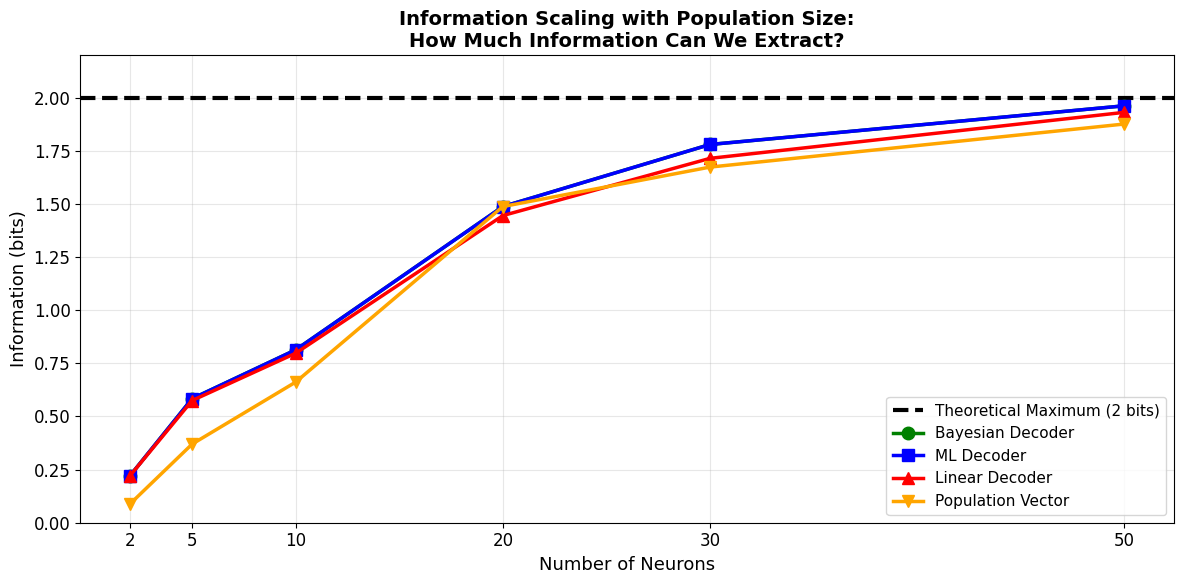

In [ ]:
# Plot information scaling
plt.figure(figsize=(12, 6))

# Perfect discrimination line (this is the TRUE theoretical maximum)
plt.axhline(y=np.log2(n_stimuli), color='black', linestyle='--',
            linewidth=3, label=f'Theoretical Maximum ({np.log2(n_stimuli):.0f} bits)')

# Decoder information
plt.plot(population_sizes, bayesian_info, 'g-', linewidth=2.5,
         marker='o', markersize=9, label='Bayesian Decoder')
plt.plot(population_sizes, ml_info, 'b-', linewidth=2.5,
         marker='s', markersize=9, label='ML Decoder')
plt.plot(population_sizes, linear_info, 'r-', linewidth=2.5,
         marker='^', markersize=9, label='Linear Decoder')
plt.plot(population_sizes, popvec_info, 'orange', linewidth=2.5,
         marker='v', markersize=9, label='Population Vector')

plt.xlabel('Number of Neurons', fontsize=13)
plt.ylabel('Information (bits)', fontsize=13)
plt.title('Information Scaling with Population Size:\nHow Much Information Can We Extract?',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 2.2)
plt.xticks(population_sizes)

plt.tight_layout()
plt.show()

In [ ]:
# Summary
print("\n" + "=" * 60)
print("INFORMATION ANALYSIS SUMMARY")
print("=" * 60)
theoretical_max = np.log2(n_stimuli)
print(f"\nTheoretical maximum: {theoretical_max:.3f} bits (perfect {n_stimuli}-class discrimination)")
print(f"\nWith {population_sizes[-1]} neurons:")
print(f"  Bayesian decoder:    {bayesian_info[-1]:.3f} bits ({100*bayesian_info[-1]/theoretical_max:.1f}% of maximum)")
print(f"  ML decoder:          {ml_info[-1]:.3f} bits ({100*ml_info[-1]/theoretical_max:.1f}% of maximum)")
print(f"  Linear decoder:      {linear_info[-1]:.3f} bits ({100*linear_info[-1]/theoretical_max:.1f}% of maximum)")
print(f"  Population Vector:   {popvec_info[-1]:.3f} bits ({100*popvec_info[-1]/theoretical_max:.1f}% of maximum)")


INFORMATION ANALYSIS SUMMARY

Theoretical maximum: 2.000 bits (perfect 4-class discrimination)

With 50 neurons:
  Bayesian decoder:    1.962 bits (98.1% of maximum)
  ML decoder:          1.962 bits (98.1% of maximum)
  Linear decoder:      1.932 bits (96.6% of maximum)
  Population Vector:   1.877 bits (93.8% of maximum)


Looking at the results, a few things stand out:

**1. More neurons = more information (but with diminishing returns)**

With just 2 neurons we could only extract about 0.2 bits, which is pretty bad. But as we added more neurons, the information increased quickly — by 20 neurons we were already at ~1.5 bits. After 30 neurons though, adding more didn't help much. We're hitting a ceiling close to the theoretical 2 bits.

**2. Population Vector is simpler but still pretty good**

Even though it doesn't use any probability calculations, it still got to ~94% of maximum.

---

# Heterogeneous Population with Directional Tuning

So far, our neurons had simple "preferred stimulus" responses. Real neurons often have **tuning curves** - they respond most strongly to their preferred stimulus and less to similar stimuli.

For example, neurons in visual cortex respond to oriented bars: a neuron might fire maximally for vertical lines (0°) and progressively less for tilted lines.

Here we simulate a population where each neuron has a different preferred direction, creating a **heterogeneous population** that collectively covers all possible stimuli.

In [ ]:
def gaussian_tuning_curve(stimulus, preferred, width=1.0, amplitude=20, baseline=5):
    # Circular distance (for direction stimuli)
    diff = np.abs(stimulus - preferred)
    circular_diff = np.minimum(diff, 2*np.pi - diff)

    # Gaussian response
    response = baseline + amplitude * np.exp(-circular_diff**2 / (2 * width**2))
    return response


def generate_tuning_population_data(n_neurons=8, n_stimuli=8, n_trials=100,
                                     tuning_width=0.8, noise_level=2.0):
    # Stimulus directions (evenly spaced)
    stimulus_directions = np.linspace(0, 2*np.pi, n_stimuli, endpoint=False)

    # Preferred directions for neurons (evenly spaced)
    preferred_directions = np.linspace(0, 2*np.pi, n_neurons, endpoint=False)

    # Generate responses
    all_responses = []
    all_labels = []

    for stim_idx, stim_dir in enumerate(stimulus_directions):
        for trial in range(n_trials):
            response = np.zeros(n_neurons)
            for n_idx, pref_dir in enumerate(preferred_directions):
                # Expected firing rate from tuning curve
                mean_rate = gaussian_tuning_curve(stim_dir, pref_dir,
                                                   width=tuning_width)
                # Add noise and generate spike count
                noisy_rate = max(0, mean_rate + np.random.normal(0, noise_level))
                response[n_idx] = np.random.poisson(noisy_rate)

            all_responses.append(response)
            all_labels.append(stim_idx)

    return (np.array(all_responses), np.array(all_labels),
            stimulus_directions, preferred_directions)


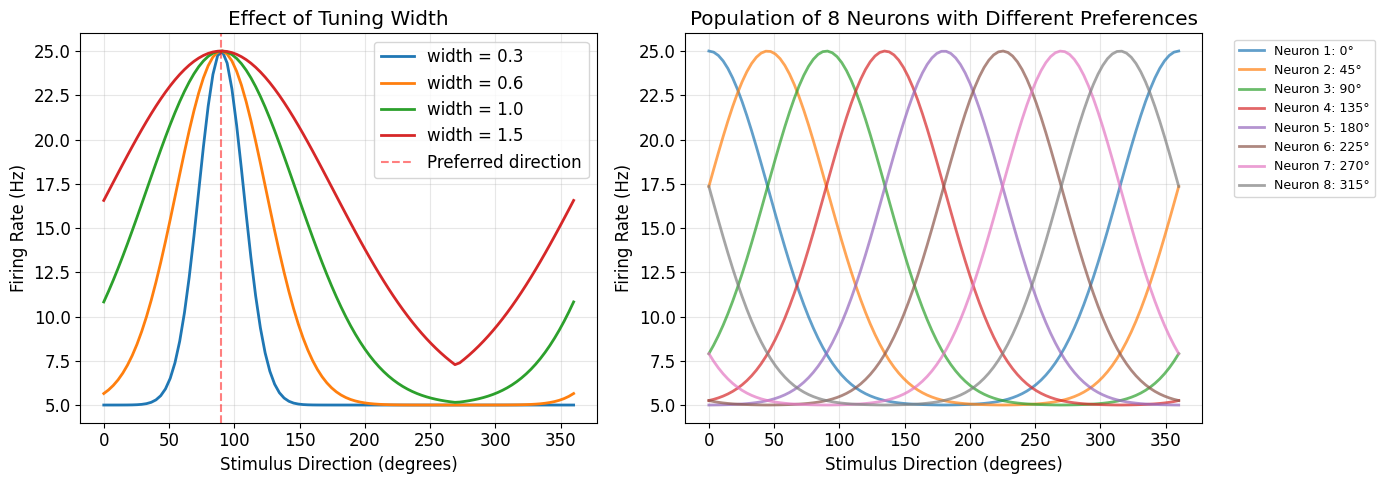


Key concept: Each neuron responds most strongly to its preferred direction
and less to other directions. Together, the population covers all directions.


In [ ]:
# Visualize the tuning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot tuning curves for different widths
theta_range = np.linspace(0, 2*np.pi, 100)
widths = [0.3, 0.6, 1.0, 1.5]

for w in widths:
    response = [gaussian_tuning_curve(t, np.pi/2, width=w) for t in theta_range]
    axes[0].plot(np.degrees(theta_range), response, linewidth=2, label=f'width = {w}')

axes[0].axvline(90, color='red', linestyle='--', alpha=0.5, label='Preferred direction')
axes[0].set_xlabel('Stimulus Direction (degrees)')
axes[0].set_ylabel('Firing Rate (Hz)')
axes[0].set_title('Effect of Tuning Width')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot population of tuning curves
n_neurons_plot = 8
preferred_dirs = np.linspace(0, 2*np.pi, n_neurons_plot, endpoint=False)

for i, pref in enumerate(preferred_dirs):
    response = [gaussian_tuning_curve(t, pref, width=0.8) for t in theta_range]
    axes[1].plot(np.degrees(theta_range), response, linewidth=2, alpha=0.7,
                 label=f'Neuron {i+1}: {np.degrees(pref):.0f}°')

axes[1].set_xlabel('Stimulus Direction (degrees)')
axes[1].set_ylabel('Firing Rate (Hz)')
axes[1].set_title('Population of 8 Neurons with Different Preferences')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey concept: Each neuron responds most strongly to its preferred direction")
print("and less to other directions. Together, the population covers all directions.")

Generated data:
  - 8 stimulus directions
  - 8 neurons
  - 800 total trials
  - Stimulus directions: [  0  45  90 135 180 225 270 315]°
  - Neuron preferences:  [  0  45  90 135 180 225 270 315]°


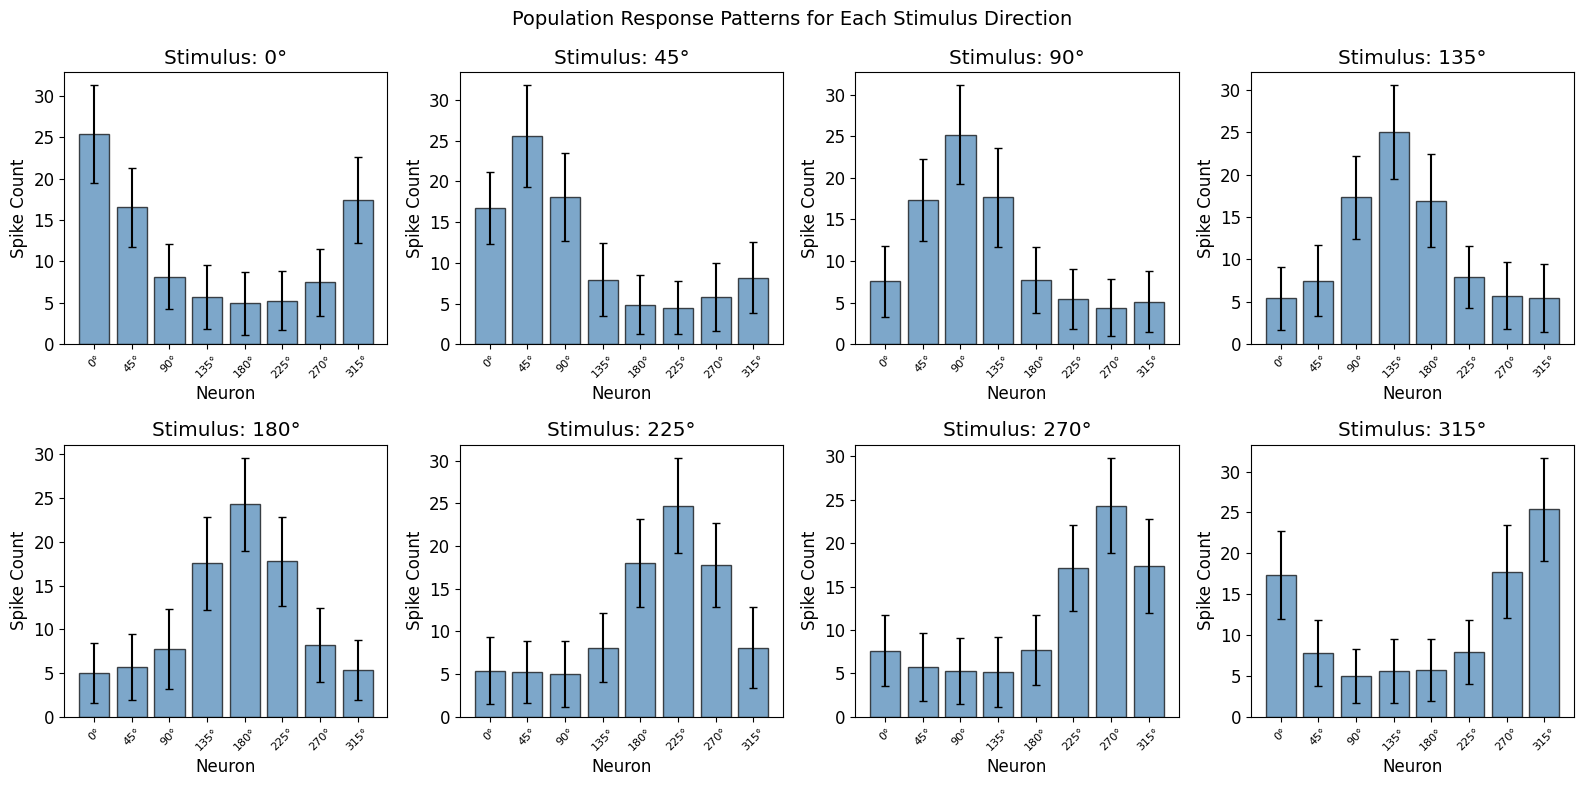

In [ ]:
# Generate population data
# Using 8 stimuli (not 4) to make the task harder
responses, labels, stim_dirs, pref_dirs = generate_tuning_population_data(
    n_neurons=8, n_stimuli=8, n_trials=100, tuning_width=0.8, noise_level=3.0
)

print(f"Generated data:")
print(f"  - {len(np.unique(labels))} stimulus directions")
print(f"  - {responses.shape[1]} neurons")
print(f"  - {responses.shape[0]} total trials")
print(f"  - Stimulus directions: {np.degrees(stim_dirs).astype(int)}°")
print(f"  - Neuron preferences:  {np.degrees(pref_dirs).astype(int)}°")

# Visualize mean population response for each stimulus
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for stim_idx in range(8):
    trials = responses[labels == stim_idx]
    mean_resp = trials.mean(axis=0)
    std_resp = trials.std(axis=0)

    axes[stim_idx].bar(range(8), mean_resp, yerr=std_resp, capsize=3,
                       alpha=0.7, color='steelblue', edgecolor='black')
    axes[stim_idx].set_xlabel('Neuron')
    axes[stim_idx].set_ylabel('Spike Count')
    axes[stim_idx].set_title(f'Stimulus: {np.degrees(stim_dirs[stim_idx]):.0f}°')
    axes[stim_idx].set_xticks(range(8))
    axes[stim_idx].set_xticklabels([f'{np.degrees(p):.0f}°' for p in pref_dirs],
                                    fontsize=8, rotation=45)

plt.suptitle('Population Response Patterns for Each Stimulus Direction', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def population_vector_decode(responses, preferred_directions, stimulus_directions):
    """
    Decode stimulus using population vector method.

    Each neuron 'votes' for its preferred direction, weighted by its firing rate.
    The population vector points toward the decoded direction.
    """
    n_trials = responses.shape[0]
    predictions = np.zeros(n_trials, dtype=int)

    for trial in range(n_trials):
        # Compute population vector (in 2D for circular stimuli)
        pv_x = np.sum(responses[trial] * np.cos(preferred_directions))
        pv_y = np.sum(responses[trial] * np.sin(preferred_directions))

        # Decoded direction is the angle of the population vector
        decoded_direction = np.arctan2(pv_y, pv_x)
        if decoded_direction < 0:
            decoded_direction += 2 * np.pi

        # Find closest stimulus
        distances = np.abs(stimulus_directions - decoded_direction)
        circular_distances = np.minimum(distances, 2*np.pi - distances)
        predictions[trial] = np.argmin(circular_distances)

    return predictions

DECODER COMPARISON ON HETEROGENEOUS POPULATION
Task: Discriminate 8 directions
Chance level: 12.5%
------------------------------------------------------------
1. Bayesian Decoder:       90.8%
2. Maximum Likelihood:     90.8%
3. Linear Classifier:      88.8%
4. Population Vector:      89.2%
------------------------------------------------------------


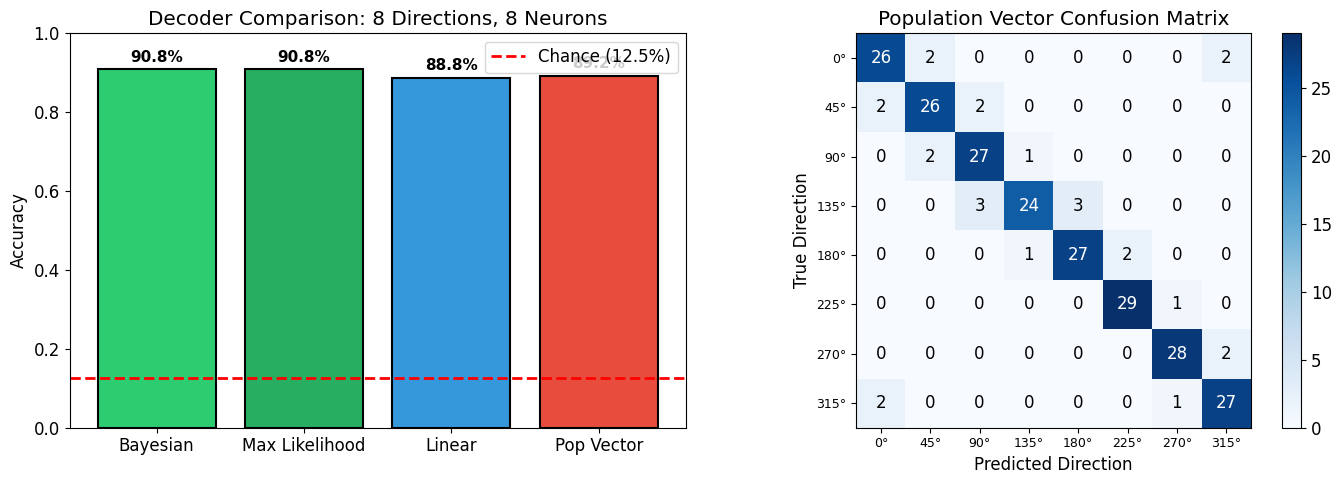

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    responses, labels, test_size=0.3, random_state=42, stratify=labels
)

print("=" * 60)
print("DECODER COMPARISON ON HETEROGENEOUS POPULATION")
print("=" * 60)
print(f"Task: Discriminate {len(np.unique(labels))} directions")
print(f"Chance level: {100/len(np.unique(labels)):.1f}%")
print("-" * 60)

# 1. Bayesian (Gaussian Naive Bayes)
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb.predict(X_test))
print(f"1. Bayesian Decoder:       {nb_acc:.1%}")

# 2. Maximum Likelihood (same as Bayesian with uniform prior)
ml_acc = nb_acc  # Equivalent for this setup
print(f"2. Maximum Likelihood:     {ml_acc:.1%}")

# 3. Linear Classifier
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"3. Linear Classifier:      {lr_acc:.1%}")

# 4. Population Vector
pv_pred = population_vector_decode(X_test, pref_dirs, stim_dirs)
pv_acc = accuracy_score(y_test, pv_pred)
print(f"4. Population Vector:      {pv_acc:.1%}")

print("-" * 60)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
decoder_names = ['Bayesian', 'Max Likelihood', 'Linear', 'Pop Vector']
accuracies = [nb_acc, ml_acc, lr_acc, pv_acc]
colors = ['#2ecc71', '#27ae60', '#3498db', '#e74c3c']

bars = axes[0].bar(decoder_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=1/8, color='red', linestyle='--', linewidth=2, label='Chance (12.5%)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Decoder Comparison: 8 Directions, 8 Neurons')
axes[0].set_ylim(0, 1)
axes[0].legend()

for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1%}', ha='center', fontsize=11, fontweight='bold')

# Confusion matrix for Population Vector (most interesting)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pv_pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xlabel('Predicted Direction')
axes[1].set_ylabel('True Direction')
axes[1].set_title('Population Vector Confusion Matrix')
axes[1].set_xticks(range(8))
axes[1].set_yticks(range(8))
axes[1].set_xticklabels([f'{d:.0f}°' for d in np.degrees(stim_dirs)], fontsize=9)
axes[1].set_yticklabels([f'{d:.0f}°' for d in np.degrees(stim_dirs)], fontsize=9)
plt.colorbar(im, ax=axes[1])

# Add values to confusion matrix
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()


Effect of Tuning Width on Decoding Accuracy:
Width = 0.3: Bayesian 99.6%, Linear 97.9%, PopVector 73.8%
Width = 0.5: Bayesian 95.4%, Linear 94.6%, PopVector 81.7%
Width = 0.8: Bayesian 92.9%, Linear 89.2%, PopVector 89.6%
Width = 1.0: Bayesian 88.8%, Linear 87.1%, PopVector 90.8%
Width = 1.5: Bayesian 80.0%, Linear 81.2%, PopVector 81.7%
Width = 2.0: Bayesian 70.8%, Linear 69.6%, PopVector 66.7%


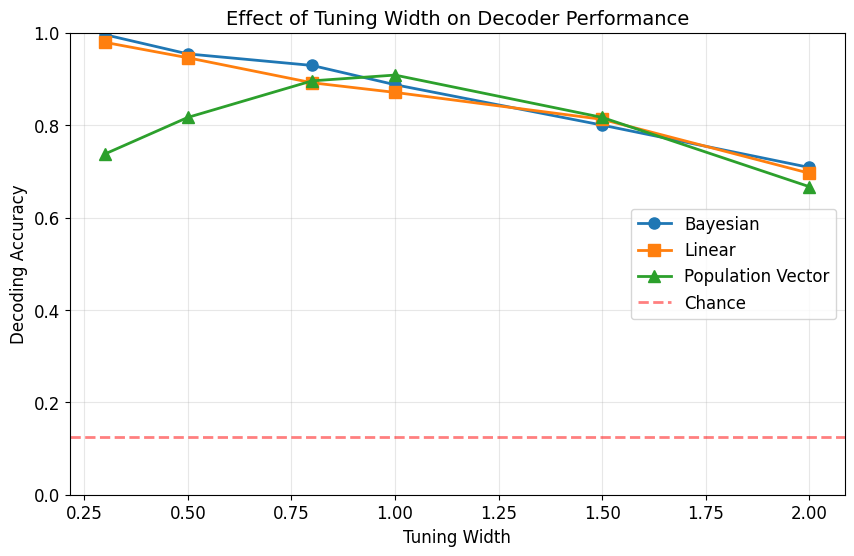


Key finding: There's an optimal tuning width!
- Too narrow: neurons don't cover all directions well
- Too broad: neurons can't discriminate between similar directions


In [ ]:
# Test how tuning width affects decoding
tuning_widths = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

results = {'width': [], 'Bayesian': [], 'Linear': [], 'PopVector': []}

print("\nEffect of Tuning Width on Decoding Accuracy:")
print("=" * 50)

for width in tuning_widths:
    # Generate data with this tuning width
    resp, lab, s_dirs, p_dirs = generate_tuning_population_data(
        n_neurons=8, n_stimuli=8, n_trials=100,
        tuning_width=width, noise_level=3.0
    )

    X_tr, X_te, y_tr, y_te = train_test_split(resp, lab, test_size=0.3,
                                               random_state=42, stratify=lab)

    # Bayesian
    nb = GaussianNB()
    nb.fit(X_tr, y_tr)
    nb_acc = accuracy_score(y_te, nb.predict(X_te))

    # Linear
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr, y_tr)
    lr_acc = accuracy_score(y_te, lr.predict(X_te))

    # Population Vector
    pv_pred = population_vector_decode(X_te, p_dirs, s_dirs)
    pv_acc = accuracy_score(y_te, pv_pred)

    results['width'].append(width)
    results['Bayesian'].append(nb_acc)
    results['Linear'].append(lr_acc)
    results['PopVector'].append(pv_acc)

    print(f"Width = {width:.1f}: Bayesian {nb_acc:.1%}, Linear {lr_acc:.1%}, PopVector {pv_acc:.1%}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(results['width'], results['Bayesian'], 'o-', linewidth=2, markersize=8, label='Bayesian')
plt.plot(results['width'], results['Linear'], 's-', linewidth=2, markersize=8, label='Linear')
plt.plot(results['width'], results['PopVector'], '^-', linewidth=2, markersize=8, label='Population Vector')
plt.axhline(y=1/8, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Chance')

plt.xlabel('Tuning Width', fontsize=12)
plt.ylabel('Decoding Accuracy', fontsize=12)
plt.title('Effect of Tuning Width on Decoder Performance', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

print("\nKey finding: There's an optimal tuning width!")
print("- Too narrow: neurons don't cover all directions well")
print("- Too broad: neurons can't discriminate between similar directions")

### Overview
**1. All decoders work well for direction discrimination**

With 8 neurons and 8 directions, all decoders achieved around 90% accuracy. This shows that the population of neurons with different preferred directions successfully encodes stimulus information.

**2. Errors make sense**

Looking at the confusion matrix, most mistakes happen between neighboring directions (e.g., 45° gets confused with 0° or 90°, but never with 180°). Directions that are close together produce similar population responses because of overlapping tuning curves.

**3. Tuning width has different effects on different decoders**

This is the most interesting finding:
- **Bayesian and Linear** work best with narrow tuning (high selectivity). They can exploit the sharp differences between neuron responses.
- **Population Vector** actually performs poorly with very narrow tuning (74% at width=0.3) but improves as tuning gets broader, peaking around width=1.0 (~90%).

Why? Population Vector works by averaging, it needs multiple neurons to be active for each stimulus. With very narrow tuning, only one neuron fires strongly, which makes the vector estimate noisy.

**4. Too broad is bad for everyone**

When tuning gets too broad (width > 1.5), all decoders suffer. The neurons become so unselective that they all respond similarly to every stimulus — there's simply less information in the population response.